# Taking a Look at the GenFlix A/B Test Data

So, we're finally digging into the data from the GenFlix A/B test simulation. The whole point was to figure out if the AI-generated synopses (Group B) actually moved the needle on click-through rates compared to our original ones (Group A). We're trying to see if we've got a genuine, statistically significant difference, or if the variation we're seeing is just random noise.

To get to the bottom of this, we'll start by getting the simulation data organized. From there, we'll compare the core performance numbers for both groups side-by-side: total impressions, clicks, and of course, the final click-through rate. A simple difference in numbers doesn't tell the whole story, so we need to be sure it's statistically sound. That’s what the Chi-Squared test is for—it'll tell us if the outcome is a fluke or the real deal. We'll also create some visuals, since a good chart can make the findings much clearer than a table of numbers.

## 1. Import necessary libraries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from pathlib import Path

sns.set_theme(style="whitegrid")

## 2. Load and Inspect the Data

In [2]:
try:
    notebook_path = Path().absolute()
    BASE_DIR = notebook_path.parent
except:
    BASE_DIR = Path.cwd().parent

SIMULATION_RESULTS_PATH = BASE_DIR / "data" / "processed" / "simulation_results.csv"



try:
    df = pd.read_csv(SIMULATION_RESULTS_PATH)
    print("Data loaded successfully!")
    print(f"Dataset contains {len(df)} records.")
except FileNotFoundError:
    print(f"Error: File not found at {SIMULATION_RESULTS_PATH}")
    print("Please make sure you have run 'python src/ab_simulator.py' first.")


if 'df' in locals():
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

Data loaded successfully!
Dataset contains 100000 records.

First 5 rows of the dataset:


,user_id,group,show_id,clicked
0,0,B,s8228,0
1,1,A,s1763,0
2,2,A,s7636,1
3,3,A,s2909,0
4,4,A,s6883,0


## 3. Calculate Performance Metrics

In [3]:
summary_df = df.groupby('group').agg(
    impressions=('user_id', 'count'),
    clicks=('clicked', 'sum')
)

summary_df['ctr'] = (summary_df['clicks'] / summary_df['impressions'])

print("Performance Summary by Group:")
display(summary_df)

summary_df['ctr_percent'] = summary_df['ctr'].apply(lambda x: f'{x:.2%}')
print("\nPerformance Summary with Percentage CTR:")
display(summary_df[['impressions', 'clicks', 'ctr_percent']])

Performance Summary by Group:


,impressions,clicks,ctr
group,,,
A,50241,2010,0.040007
B,49759,2745,0.055166



Performance Summary with Percentage CTR:


,impressions,clicks,ctr_percent
group,,,
A,50241,2010,4.00%
B,49759,2745,5.52%


## 4. Statistical Significance Test (Chi-Squared)

The difference in CTRs looks promising, but is it statistically significant? We'll use the **Chi-Squared Test for Independence** to find out.

*   **Null Hypothesis (H₀):** There is no association between the group (A or B) and the user's clicking behavior. The observed difference in CTR is due to random chance.
*   **Alternative Hypothesis (H₁):** There is a significant association between the group and the clicking behavior.

We'll use a significance level (alpha) of 0.05. If the p-value is less than 0.05, we reject the null hypothesis.

In [4]:
contingency_table = pd.crosstab(df['group'], df['clicked'])
contingency_table.columns = ['no_click', 'click']
print("Contingency Table:")
display(contingency_table)


chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")


alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: The result is statistically significant (p < {alpha}).")
    print("We reject the null hypothesis. The AI-generated synopsis had a significant effect on the click-through rate.")
else:
    print(f"\nConclusion: The result is not statistically significant (p >= {alpha}).")
    print("We fail to reject the null hypothesis. The difference in CTRs could be due to random chance.")

Contingency Table:


,no_click,click
group,,
A,48231,2010
B,47014,2745



Chi-Squared Statistic: 126.5075
P-value: 0.0000

Conclusion: The result is statistically significant (p < 0.05).
We reject the null hypothesis. The AI-generated synopsis had a significant effect on the click-through rate.


## 5. Visualize the Results

C:\Users\orhan\AppData\Local\Temp\ipykernel_19980\2729910214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='group', y='ctr', data=plot_df, palette=['#4c72b0', '#55a868'])


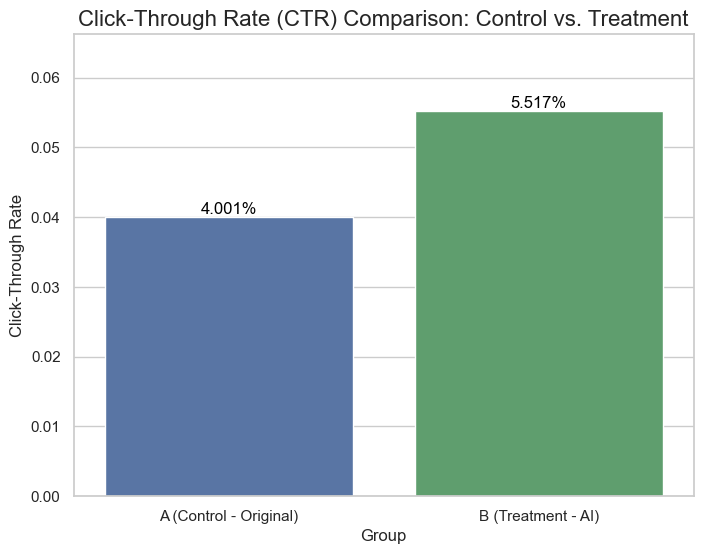

In [5]:
plot_df = summary_df.reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='group', y='ctr', data=plot_df, palette=['#4c72b0', '#55a868'])

for index, row in plot_df.iterrows():
    ax.text(index, row.ctr + 0.0005, f'{row.ctr:.3%}', 
            color='black', ha="center", fontsize=12)

plt.title('Click-Through Rate (CTR) Comparison: Control vs. Treatment', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Click-Through Rate', fontsize=12)
plt.ylim(0, max(plot_df['ctr']) * 1.2)
plt.xticks([0, 1], ['A (Control - Original)', 'B (Treatment - AI)'])

plt.show()

Summary with 95% Confidence Intervals:


,ctr_percent,ci_lower,ci_upper
group,,,
A,4.00%,0.038294,0.041721
B,5.52%,0.053160,0.057172


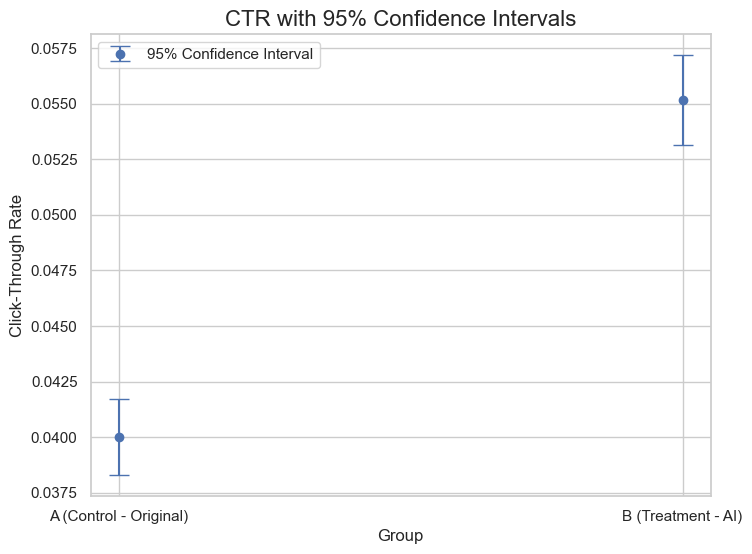

In [6]:
conf_intervals = {}
for group in summary_df.index:
    clicks = summary_df.loc[group, 'clicks']
    impressions = summary_df.loc[group, 'impressions']
    
    lower_bound, upper_bound = proportion_confint(count=clicks, nobs=impressions, alpha=0.05, method='normal')
    conf_intervals[group] = {'lower': lower_bound, 'upper': upper_bound}

summary_df['ci_lower'] = summary_df.index.map(lambda g: conf_intervals[g]['lower'])
summary_df['ci_upper'] = summary_df.index.map(lambda g: conf_intervals[g]['upper'])
summary_df['error'] = summary_df['ci_upper'] - summary_df['ctr']
print("Summary with 95% Confidence Intervals:")
display(summary_df[['ctr_percent', 'ci_lower', 'ci_upper']])

plt.figure(figsize=(8, 6))
plt.errorbar(x=summary_df.index, 
             y=summary_df['ctr'], 
             yerr=summary_df['error'], 
             fmt='o',
             linestyle='', 
             capsize=7,
             label='95% Confidence Interval')

plt.title('CTR with 95% Confidence Intervals', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Click-Through Rate', fontsize=12)
plt.xticks([0, 1], ['A (Control - Original)', 'B (Treatment - AI)'])
plt.grid(True, axis='y')
plt.legend()
plt.show()

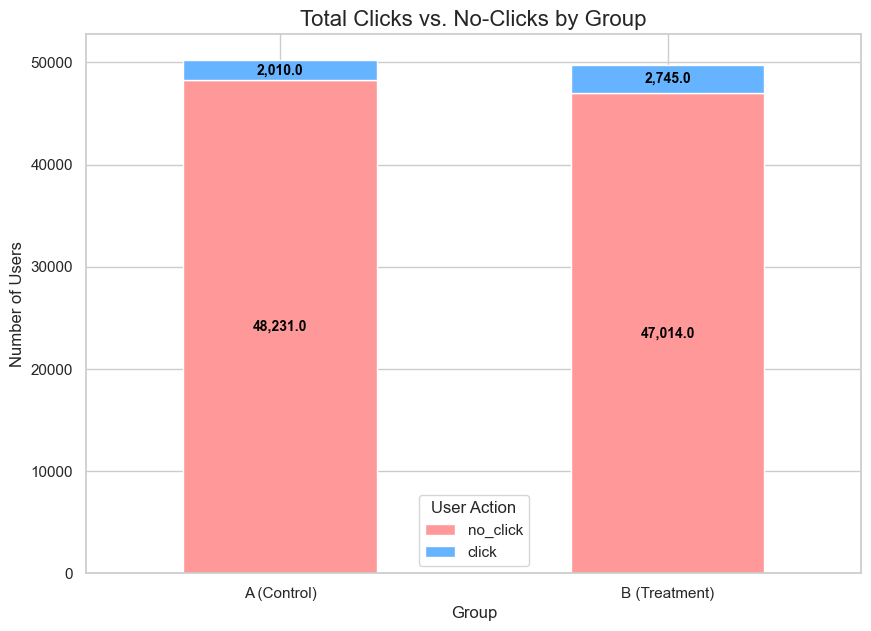

In [7]:
ax = contingency_table.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 7),
    color=['#ff9999','#66b3ff'],
    rot=0
)

plt.title('Total Clicks vs. No-Clicks by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.legend(title='User Action')
plt.xticks([0, 1], ['A (Control)', 'B (Treatment)'])

for c in ax.containers:
    labels = [f'{v.get_height():,}' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='black', weight='bold')

plt.show()